In [1]:
#@title CELL 1 — Install Libraries
print("📦 Installing libraries...")
!pip install timm gradio scikit-learn --upgrade -q

import timm, gradio, sklearn
print(f"✅ timm    : {timm.__version__}")
print(f"✅ gradio  : {gradio.__version__}")
print(f"✅ sklearn : {sklearn.__version__}")
print("✅ All libraries ready!")

📦 Installing libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires starlette<1.0.0,>=0.49.1, but you have starlette 1.2.1 which is incompatible.
✅ timm    : 1.0.27
✅ gradio  : 6.15.2
✅ sklearn : 1.8.0
✅ All libraries ready!


In [2]:
#@title CELL 2 — Drive + Kaggle + Dataset
import os, glob
from google.colab import drive, files

# Mount Drive
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/ViT_HAM10000_Binary'
os.makedirs(f'{DRIVE}/assets', exist_ok=True)
print(f"✅ Drive mounted → {DRIVE}")

# Kaggle Auth
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("\n📁 Upload kaggle.json:")
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    !cp kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
    print("✅ Kaggle authenticated!")
else:
    print("✅ Kaggle already authenticated!")

# Download Dataset
BASE = '/content/ham10000'
if os.path.exists(f'{BASE}/HAM10000_metadata.csv'):
    print("✅ Dataset already present — skipping download!")
else:
    print("⬇️  Downloading HAM10000 (~2GB, 3-5 min)...")
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 \
        -p /content/ham10000 --unzip
    print("✅ Download complete!")

# Verify
all_images  = glob.glob(f'{BASE}/**/*.jpg', recursive=True)
unique_imgs = len(set(
    os.path.splitext(os.path.basename(p))[0]
    for p in all_images))
print(f"\n{'─'*40}")
print(f"  Metadata      : ✅ Found")
print(f"  Unique images : {unique_imgs}")
print(f"{'─'*40}")
print("✅ Dataset ready!")

Mounted at /content/drive
✅ Drive mounted → /content/drive/MyDrive/ViT_HAM10000_Binary

📁 Upload kaggle.json:


Saving kaggle.json to kaggle.json
✅ Kaggle authenticated!
⬇️  Downloading HAM10000 (~2GB, 3-5 min)...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [04:57<00:00, 18.8MB/s]

✅ Download complete!

────────────────────────────────────────
  Metadata      : ✅ Found
  Unique images : 10015
────────────────────────────────────────
✅ Dataset ready!


In [3]:
#@title CELL 3 — Imports + Config
import os, glob, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from PIL import Image
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as tv_models
import timm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score,
                              recall_score, precision_score,
                              confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# ── Paths ─────────────────────────────────────────────
BASE      = '/content/ham10000'
DRIVE     = '/content/drive/MyDrive/ViT_HAM10000_Binary'
SAVE_PATH = f'{DRIVE}/best_vit_binary.pth'

# ── Hyperparameters ───────────────────────────────────
SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 30
PATIENCE      = 7
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTH  = 0.1
MIXUP_ALPHA   = 0.2
UNFREEZE_FROM = 6
NUM_CLASSES   = 2

# ── Seeds ─────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

# ── Label Maps ────────────────────────────────────────
# Binary: 0 = Benign, 1 = Malignant
label_map = {
    'nv'   : 0,   # Benign
    'bkl'  : 0,   # Benign
    'df'   : 0,   # Benign
    'vasc' : 0,   # Benign
    'mel'  : 1,   # Malignant
    'bcc'  : 1,   # Malignant
    'akiec': 1,   # Malignant
}
label_names      = {0: 'Benign', 1: 'Malignant'}
class_full_names = {
    'nv'   : 'Melanocytic Nevi     → Benign',
    'bkl'  : 'Benign Keratosis     → Benign',
    'df'   : 'Dermatofibroma       → Benign',
    'vasc' : 'Vascular Lesion      → Benign',
    'mel'  : 'Melanoma             → Malignant',
    'bcc'  : 'Basal Cell Carcinoma → Malignant',
    'akiec': 'Actinic Keratosis    → Malignant',
}

print(f"\n{'─'*45}")
print(f"  Task          : Binary (Benign vs Malignant)")
print(f"  NUM_CLASSES   : {NUM_CLASSES}")
print(f"  BATCH_SIZE    : {BATCH_SIZE}")
print(f"  EPOCHS        : {EPOCHS}")
print(f"  PATIENCE      : {PATIENCE}")
print(f"  LR            : {LR}")
print(f"  UNFREEZE_FROM : Block {UNFREEZE_FROM}")
print(f"  LABEL_SMOOTH  : {LABEL_SMOOTH}")
print(f"  MIXUP_ALPHA   : {MIXUP_ALPHA}")
print(f"{'─'*45}")
print("✅ Config ready!")

✅ Device: cuda

─────────────────────────────────────────────
  Task          : Binary (Benign vs Malignant)
  NUM_CLASSES   : 2
  BATCH_SIZE    : 32
  EPOCHS        : 30
  PATIENCE      : 7
  LR            : 0.0001
  UNFREEZE_FROM : Block 6
  LABEL_SMOOTH  : 0.1
  MIXUP_ALPHA   : 0.2
─────────────────────────────────────────────
✅ Config ready!


📊 Total images : 10015

Original 7-class distribution:
  nv    : 6705  🟢 Benign
  mel   : 1113  🔴 Malignant
  bkl   : 1099  🟢 Benign
  bcc   :  514  🔴 Malignant
  akiec :  327  🔴 Malignant
  vasc  :  142  🟢 Benign
  df    :  115  🟢 Benign

Binary distribution:
  Benign    : 8061
  Malignant : 1954
  Ratio     : 4.1:1


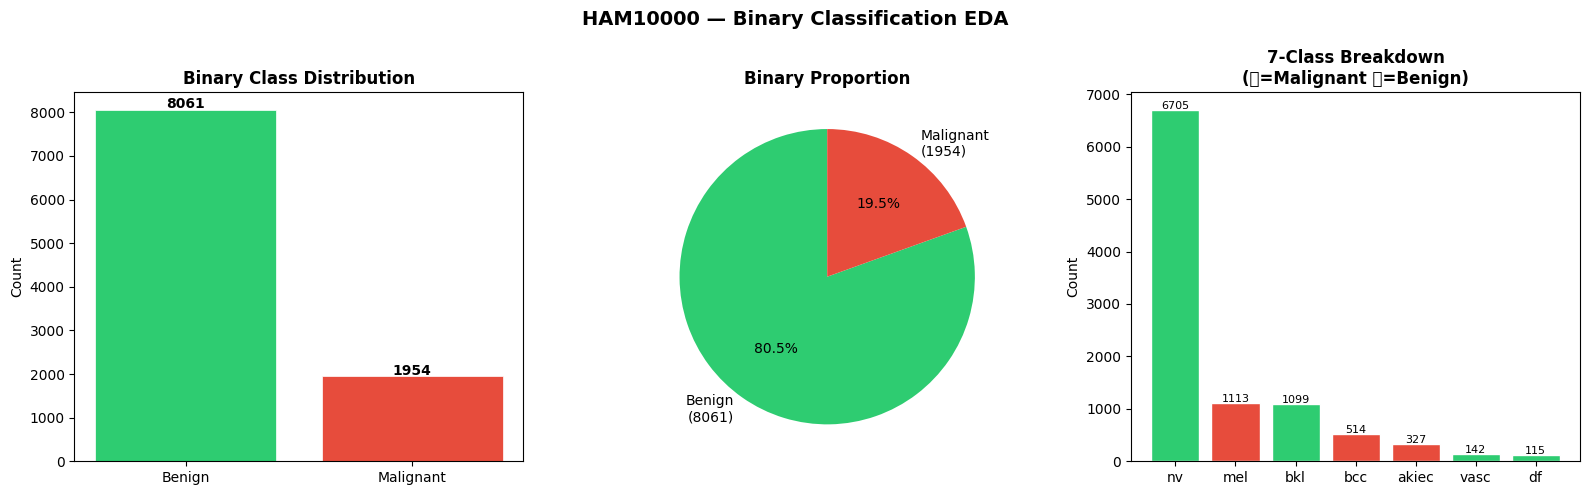

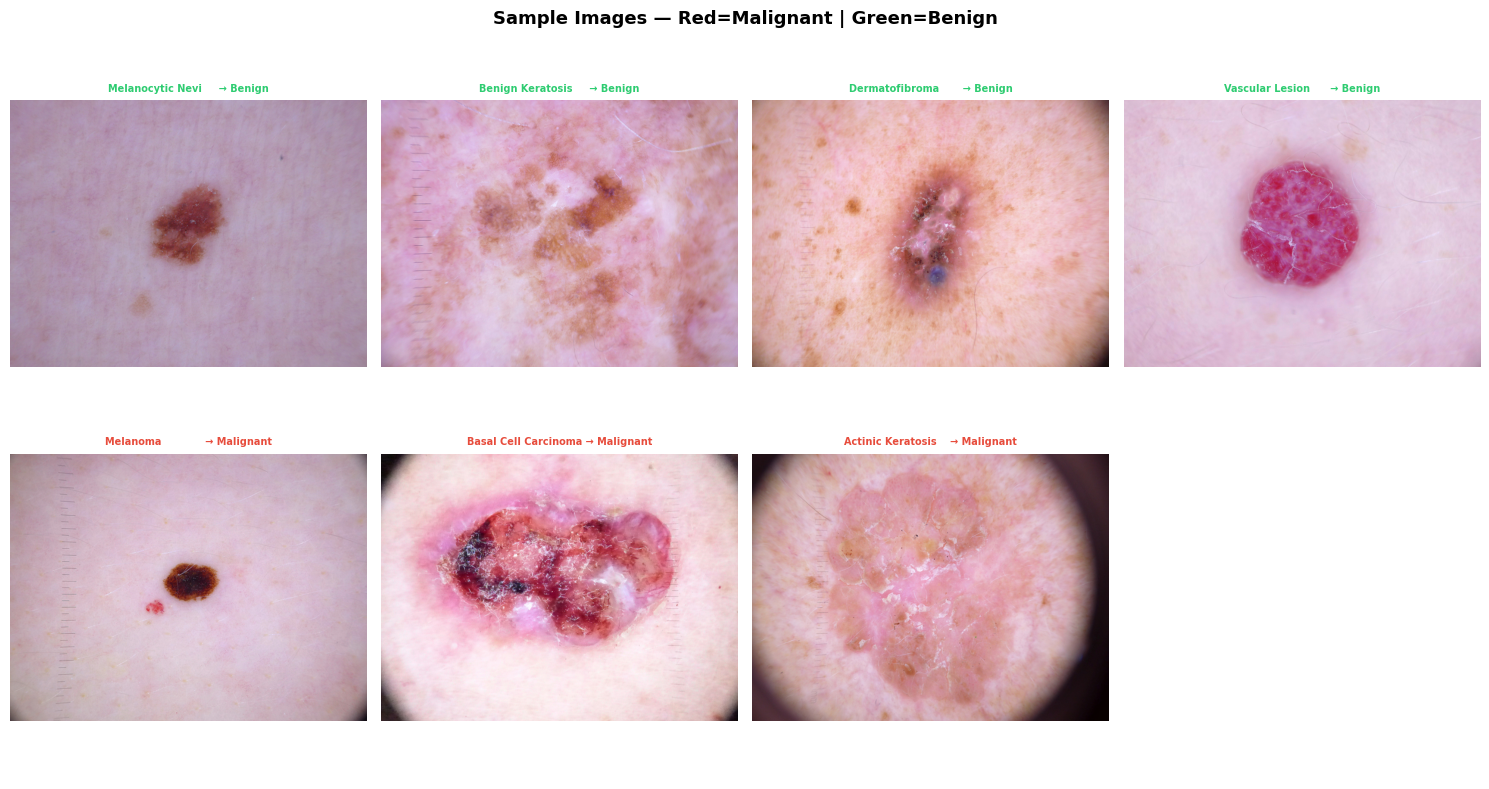

✅ EDA complete!


In [4]:
#@title CELL 4 — EDA

# Load metadata
meta = pd.read_csv(f'{BASE}/HAM10000_metadata.csv')

# Map image paths
all_images = glob.glob(f'{BASE}/**/*.jpg', recursive=True)
image_path_dict = {}
for path in all_images:
    img_id = os.path.splitext(os.path.basename(path))[0]
    image_path_dict[img_id] = path

meta['path']         = meta['image_id'].map(image_path_dict)
meta['label']        = meta['dx'].map(label_map)
meta['label_name']   = meta['label'].map(label_names)
meta                 = meta.dropna(subset=['path']).reset_index(drop=True)

print(f"📊 Total images : {len(meta)}")
print(f"\nOriginal 7-class distribution:")
for dx, cnt in meta['dx'].value_counts().items():
    tag = '🔴 Malignant' if label_map[dx]==1 else '🟢 Benign'
    print(f"  {dx:6s}: {cnt:4d}  {tag}")

print(f"\nBinary distribution:")
print(f"  Benign    : {(meta['label']==0).sum()}")
print(f"  Malignant : {(meta['label']==1).sum()}")
print(f"  Ratio     : {(meta['label']==0).sum()/(meta['label']==1).sum():.1f}:1")

# ── Plot 1: Binary Distribution ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Binary bar
binary_counts = meta['label_name'].value_counts()
colors_bin    = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(binary_counts.index,
                   binary_counts.values,
                   color=colors_bin, edgecolor='white', lw=0.5)
for bar, val in zip(bars, binary_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+30, str(val),
                 ha='center', fontweight='bold')
axes[0].set_title('Binary Class Distribution',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Binary pie
axes[1].pie(binary_counts.values,
            labels=[f"{n}\n({v})"
                    for n,v in zip(binary_counts.index,
                                   binary_counts.values)],
            colors=colors_bin, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':10})
axes[1].set_title('Binary Proportion',
                  fontsize=12, fontweight='bold')

# 7-class breakdown colored by binary label
dx_counts = meta['dx'].value_counts()
bar_colors = ['#e74c3c' if label_map[dx]==1
              else '#2ecc71' for dx in dx_counts.index]
axes[2].bar(dx_counts.index, dx_counts.values,
            color=bar_colors, edgecolor='white')
axes[2].set_title('7-Class Breakdown\n(🔴=Malignant 🟢=Benign)',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')
for bar, val in zip(axes[2].patches, dx_counts.values):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+20, str(val),
                 ha='center', fontsize=8)

plt.suptitle('HAM10000 — Binary Classification EDA',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE}/assets/class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Sample Images ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()
for i, (dx, name) in enumerate(class_full_names.items()):
    row   = meta[meta['dx']==dx].iloc[0]
    img   = Image.open(row['path']).convert('RGB')
    color = '#e74c3c' if label_map[dx]==1 else '#2ecc71'
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=7,
                      color=color, fontweight='bold')
    axes[i].axis('off')
axes[-1].axis('off')
plt.suptitle('Sample Images — Red=Malignant | Green=Benign',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE}/assets/sample_images.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete!")

In [5]:
#@title CELL 5 — Split + Dataset + DataLoaders

# Stratified 70/15/15 split
train_df, temp_df = train_test_split(
    meta, test_size=0.30,
    stratify=meta['label'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['label'], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"{'─'*45}")
print(f"  Train : {len(train_df):5d} images (70%)")
print(f"    Benign    : {(train_df['label']==0).sum()}")
print(f"    Malignant : {(train_df['label']==1).sum()}")
print(f"  Val   : {len(val_df):5d} images (15%)")
print(f"  Test  : {len(test_df):5d} images (15%)")
print(f"{'─'*45}")

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.1),
    transforms.RandomAffine(
        degrees=0, translate=(0.1,0.1),
        scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
tta_transforms = [
    base_transforms,
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
]

# Dataset
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label

# DataLoaders
train_loader = DataLoader(
    SkinDataset(train_df, train_transforms),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True)
val_loader = DataLoader(
    SkinDataset(val_df, base_transforms),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True)
test_loader = DataLoader(
    SkinDataset(test_df, base_transforms),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True)

# Class weights — balanced only, no extra boost
weights = compute_class_weight(
    'balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values)
class_weights_tensor = torch.tensor(
    weights, dtype=torch.float32)

print(f"\nClass Weights (balanced only):")
print(f"  Benign    : {weights[0]:.4f}")
print(f"  Malignant : {weights[1]:.4f}")
print("✅ DataLoaders ready!")

─────────────────────────────────────────────
  Train :  7010 images (70%)
    Benign    : 5642
    Malignant : 1368
  Val   :  1502 images (15%)
  Test  :  1503 images (15%)
─────────────────────────────────────────────

Class Weights (balanced only):
  Benign    : 0.6212
  Malignant : 2.5621
✅ DataLoaders ready!


In [6]:
#@title CELL 6 — MixUp + Label Smoothing

def mixup_data(x, y, alpha=MIXUP_ALPHA):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    mixed = lam * x + (1-lam) * x[index]
    return mixed, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam*criterion(pred,y_a) + (1-lam)*criterion(pred,y_b)

class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=2, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.cls       = classes
        self.weight    = weight
    def forward(self, pred, target):
        confidence     = 1.0 - self.smoothing
        smooth_val     = self.smoothing / (self.cls-1)
        one_hot        = torch.zeros_like(pred).scatter_(
                             1, target.unsqueeze(1), 1)
        smooth_one_hot = one_hot*confidence + \
                         (1-one_hot)*smooth_val
        log_prob       = F.log_softmax(pred, dim=1)
        if self.weight is not None:
            w    = self.weight.to(pred.device)[target]
            loss = (-(smooth_one_hot*log_prob
                      ).sum(dim=1)*w).mean()
        else:
            loss = -(smooth_one_hot*log_prob
                     ).sum(dim=1).mean()
        return loss

print("✅ MixUp + Label Smoothing ready!")
print(f"   Classes        : {NUM_CLASSES} (Binary)")
print(f"   MixUp alpha    : {MIXUP_ALPHA}")
print(f"   Label smoothing: {LABEL_SMOOTH}")

✅ MixUp + Label Smoothing ready!
   Classes        : 2 (Binary)
   MixUp alpha    : 0.2
   Label smoothing: 0.1


In [7]:
#@title CELL 7 — Load ViT-B/16 (Binary)

if os.path.exists(SAVE_PATH):
    print("✅ Saved model found in Drive — loading!")
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=False, num_classes=NUM_CLASSES)
    model.load_state_dict(
        torch.load(SAVE_PATH, map_location=device))
    model = model.to(device)
    model.eval()
    ALREADY_TRAINED = True
    print("✅ Model loaded — skip to Cell 9!")

else:
    print("🔄 Loading pretrained ViT-B/16...")
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True, num_classes=NUM_CLASSES)

    # Freeze all
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze blocks 6-11 + head + norm
    for i in range(UNFREEZE_FROM, 12):
        for param in model.blocks[i].parameters():
            param.requires_grad = True
    for param in model.head.parameters():
        param.requires_grad = True
    for param in model.norm.parameters():
        param.requires_grad = True

    model = model.to(device)
    ALREADY_TRAINED = False

    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"\n{'─'*45}")
    print(f"  Task          : Binary Classification")
    print(f"  Output classes: {NUM_CLASSES}")
    print(f"  Unfrozen      : Blocks {UNFREEZE_FROM}–11 + head")
    print(f"  Trainable     : {trainable:,} / {total:,}")
    print(f"  Trainable %   : {100*trainable/total:.1f}%")
    print(f"{'─'*45}")
    print("✅ ViT ready!")

🔄 Loading pretrained ViT-B/16...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


─────────────────────────────────────────────
  Task          : Binary Classification
  Output classes: 2
  Unfrozen      : Blocks 6–11 + head
  Trainable     : 42,530,306 / 85,800,194
  Trainable %   : 49.6%
─────────────────────────────────────────────
✅ ViT ready!


In [8]:
#@title CELL 8 — Training (Saves All Epochs, Pick Best At End)

if ALREADY_TRAINED:
    print("✅ Skipping — model loaded from Drive!")
    train_losses=val_losses=train_accs=val_accs=[]
    mal_recalls=mal_f1s=[]

else:
    from torch.optim.lr_scheduler import (CosineAnnealingLR,
                                           LinearLR,
                                           SequentialLR)
    criterion = LabelSmoothingLoss(
        classes=NUM_CLASSES,
        smoothing=LABEL_SMOOTH,
        weight=class_weights_tensor)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)

    warmup    = LinearLR(optimizer,
                         start_factor=0.1,
                         end_factor=1.0,
                         total_iters=3)
    cosine    = CosineAnnealingLR(optimizer,
                                   T_max=EPOCHS-3,
                                   eta_min=1e-6)
    scheduler = SequentialLR(optimizer,
                              schedulers=[warmup, cosine],
                              milestones=[3])

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    mal_recalls,  mal_f1s    = [], []

    # Save every epoch's weights
    epoch_save_dir = f'{DRIVE}/epoch_checkpoints'
    os.makedirs(epoch_save_dir, exist_ok=True)
    print(f"📁 Checkpoints → {epoch_save_dir}\n")

    print("🚀 Training started!\n")
    print(f"{'Ep':>4} │{'TrLoss':>8} {'TrAcc':>7} │"
          f"{'VaLoss':>8} {'VaAcc':>7} │"
          f"{'MalRec':>8} {'MalF1':>7} │"
          f"{'LR':>9}")
    print(f"{'─'*80}")

    for epoch in range(EPOCHS):

        # ── TRAIN ──────────────────────────────────────
        model.train()
        r_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            imgs, y_a, y_b, lam = mixup_data(imgs, labels)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = mixup_criterion(criterion, out, y_a, y_b, lam)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0)
            optimizer.step()
            r_loss  += loss.item() * imgs.size(0)
            correct += out.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
        t_loss = r_loss / total
        t_acc  = correct / total

        # ── VALIDATE ───────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        v_preds, v_labels = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out    = model(imgs)
                loss   = F.cross_entropy(
                    out, labels,
                    weight=class_weights_tensor.to(device))
                v_loss    += loss.item() * imgs.size(0)
                v_correct += out.argmax(1).eq(labels).sum().item()
                v_total   += labels.size(0)
                v_preds.extend(out.argmax(1).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        v_loss     = v_loss / v_total
        v_acc      = v_correct / v_total
        cur_lr     = optimizer.param_groups[0]['lr']
        v_preds    = np.array(v_preds)
        v_labels   = np.array(v_labels)

        mal_recall = recall_score(v_labels, v_preds,
                                   pos_label=1,
                                   zero_division=0)
        mal_f1     = f1_score(v_labels, v_preds,
                               pos_label=1,
                               average='binary',
                               zero_division=0)

        train_losses.append(t_loss); val_losses.append(v_loss)
        train_accs.append(t_acc);    val_accs.append(v_acc)
        mal_recalls.append(mal_recall)
        mal_f1s.append(mal_f1)
        scheduler.step()

        # Save every epoch
        torch.save(model.state_dict(),
                   f'{epoch_save_dir}/epoch_{epoch+1:02d}.pth')

        print(f"{epoch+1:>4} │{t_loss:>8.4f} {t_acc*100:>6.2f}% │"
              f"{v_loss:>8.4f} {v_acc*100:>6.2f}% │"
              f"{mal_recall*100:>7.2f}% {mal_f1*100:>6.2f}% │"
              f"{cur_lr:>9.2e}")

    print(f"{'─'*80}")
    print(f"🏁 All {EPOCHS} epochs complete!\n")

    # ── Summary Table ───────────────────────────────────
    print(f"📋 Full Summary:")
    print(f"{'─'*55}")
    print(f"  {'Ep':>3} {'VaAcc':>7} {'MalRec':>8} {'MalF1':>7}")
    print(f"{'─'*55}")
    for i,(va,mr,mf) in enumerate(
            zip(val_accs, mal_recalls, mal_f1s)):
        print(f"  {i+1:>3} {va*100:>6.2f}%"
              f" {mr*100:>7.2f}%"
              f" {mf*100:>6.2f}%")
    print(f"{'─'*55}")
    print(f"\n✅ All epoch checkpoints saved to Drive!")
    print(f"👉 Now run Cell 8B to pick your epoch.")

📁 Checkpoints → /content/drive/MyDrive/ViT_HAM10000_Binary/epoch_checkpoints

🚀 Training started!

  Ep │  TrLoss   TrAcc │  VaLoss   VaAcc │  MalRec   MalF1 │       LR
────────────────────────────────────────────────────────────────────────────────
   1 │  0.5871  68.13% │  0.4341  83.22% │  73.72%  63.16% │ 1.00e-05
   2 │  0.5796  68.69% │  0.4184  85.62% │  72.70%  66.36% │ 4.00e-05
   3 │  0.5807  70.54% │  0.4230  73.90% │  94.20%  58.47% │ 7.00e-05
   4 │  0.5629  70.67% │  0.4263  71.57% │  95.56%  56.74% │ 1.00e-04
   5 │  0.5560  71.73% │  0.4010  83.42% │  82.94%  66.12% │ 9.97e-05
   6 │  0.5358  73.08% │  0.3683  83.09% │  83.96%  65.95% │ 9.87e-05
   7 │  0.5267  73.55% │  0.3694  84.29% │  78.50%  66.09% │ 9.70e-05
   8 │  0.5301  74.55% │  0.4699  89.21% │  59.73%  68.36% │ 9.47e-05
   9 │  0.5137  76.58% │  0.3595  83.22% │  84.64%  66.31% │ 9.19e-05
  10 │  0.5100  74.98% │  0.3707  87.22% │  77.82%  70.37% │ 8.84e-05
  11 │  0.4990  75.46% │  0.3838  87.82% │  75.09%

In [21]:
#@title CELL 8B — Pick Best Epoch

# ── CHANGE THIS NUMBER ──────────────────────────────
CHOSEN_EPOCH = 23   # <-- change this to your pick
# ────────────────────────────────────────────────────

epoch_save_dir = f'{DRIVE}/epoch_checkpoints'
chosen_path    = f'{epoch_save_dir}/epoch_{CHOSEN_EPOCH:02d}.pth'

# Load chosen epoch
model.load_state_dict(
    torch.load(chosen_path, map_location=device))
model.eval()

# Save as final model
torch.save(model.state_dict(), SAVE_PATH)

print(f"{'='*45}")
print(f"  Chosen Epoch   : {CHOSEN_EPOCH}")
print(f"  Val Accuracy   : {val_accs[CHOSEN_EPOCH-1]*100:.2f}%")
print(f"  Mal Recall     : {mal_recalls[CHOSEN_EPOCH-1]*100:.2f}%")
print(f"  Mal F1         : {mal_f1s[CHOSEN_EPOCH-1]*100:.2f}%")
print(f"{'='*45}")
print(f"✅ Epoch {CHOSEN_EPOCH} loaded as final model!")
print(f"✅ Saved to Drive as best_vit_binary.pth")
print(f"👉 Proceed to Cell 9!")

  Chosen Epoch   : 23
  Val Accuracy   : 90.01%
  Mal Recall     : 78.50%
  Mal F1         : 75.41%
✅ Epoch 23 loaded as final model!
✅ Saved to Drive as best_vit_binary.pth
👉 Proceed to Cell 9!


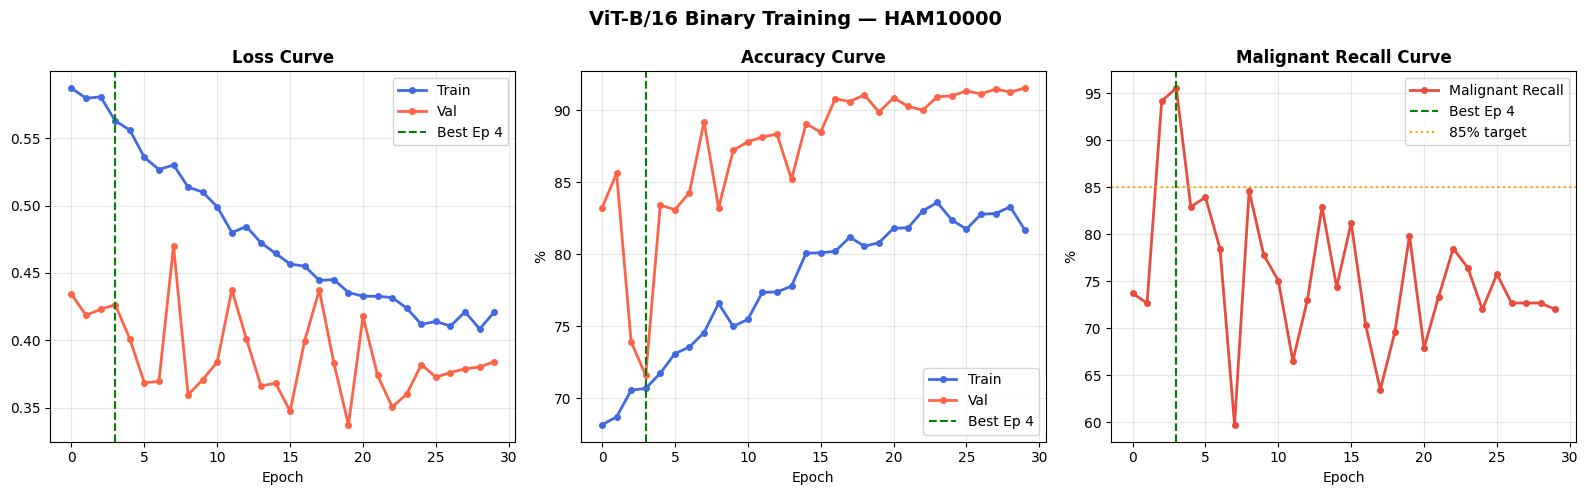

✅ Training curves saved!


In [24]:
#@title CELL 9 — Training Curves
if len(train_losses) == 0:
    print("ℹ️ No training this session — skipping")
else:
    best_ep = mal_recalls.index(max(mal_recalls))
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].plot(train_losses, label='Train',
                 color='royalblue', marker='o', ms=4, lw=2)
    axes[0].plot(val_losses, label='Val',
                 color='tomato', marker='o', ms=4, lw=2)
    axes[0].axvline(x=best_ep, color='green',
                    linestyle='--', lw=1.5,
                    label=f'Best Ep {best_ep+1}')
    axes[0].set_title('Loss Curve', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot([a*100 for a in train_accs], label='Train',
                 color='royalblue', marker='o', ms=4, lw=2)
    axes[1].plot([a*100 for a in val_accs], label='Val',
                 color='tomato', marker='o', ms=4, lw=2)
    axes[1].axvline(x=best_ep, color='green',
                    linestyle='--', lw=1.5,
                    label=f'Best Ep {best_ep+1}')
    axes[1].set_title('Accuracy Curve', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('%')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot([r*100 for r in mal_recalls],
                 color='#e74c3c', marker='o', ms=4, lw=2,
                 label='Malignant Recall')
    axes[2].axvline(x=best_ep, color='green',
                    linestyle='--', lw=1.5,
                    label=f'Best Ep {best_ep+1}')
    axes[2].axhline(y=85, color='orange',
                    linestyle=':', lw=1.5,
                    label='85% target')
    axes[2].set_title('Malignant Recall Curve',
                      fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('%')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle('ViT-B/16 Binary Training — HAM10000',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{DRIVE}/assets/training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Training curves saved!")

In [22]:
#@title CELL 10 — Full Evaluation + TTA
print("🔍 Evaluating with TTA (3 passes)...\n")

all_probs = np.zeros((len(test_df), NUM_CLASSES))
model.eval()

for t_idx, transform in enumerate(tta_transforms):
    loader = DataLoader(
        SkinDataset(test_df, transform),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True)
    batch_probs = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            batch_probs.append(
                torch.softmax(out,dim=1).cpu().numpy())
    all_probs += np.vstack(batch_probs)
    print(f"  TTA pass {t_idx+1}/3 ✅")

all_probs  /= 3
all_preds   = all_probs.argmax(axis=1)
all_labels  = test_df['label'].values
mal_probs   = all_probs[:, 1]  # probability of malignant

# ── Metrics ──────────────────────────────────────────
acc        = accuracy_score(all_labels, all_preds)
f1_macro   = f1_score(all_labels, all_preds, average='macro')
f1_w       = f1_score(all_labels, all_preds, average='weighted')
precision  = precision_score(all_labels, all_preds, pos_label=1)
mal_recall = recall_score(all_labels, all_preds, pos_label=1)
ben_recall = recall_score(all_labels, all_preds, pos_label=0)
auc_roc    = roc_auc_score(all_labels, mal_probs)

print(f"\n{'='*52}")
print(f"  {'Metric':<28} {'Score':>10}")
print(f"{'─'*52}")
print(f"  {'Test Accuracy':<28} {acc*100:>9.2f}%")
print(f"  {'Macro F1':<28} {f1_macro:>10.4f}")
print(f"  {'Weighted F1':<28} {f1_w:>10.4f}")
print(f"  {'Malignant Precision':<28} {precision*100:>9.2f}%")
print(f"  {'Malignant Recall (Sensitivity)':<28} {mal_recall*100:>9.2f}%")
print(f"  {'Benign Recall (Specificity)':<28} {ben_recall*100:>9.2f}%")
print(f"  {'AUC-ROC':<28} {auc_roc:>10.4f}")
print(f"{'='*52}\n")

print(classification_report(
    all_labels, all_preds,
    target_names=['Benign', 'Malignant'],
    digits=4))

# Save results
results = {
    "model"              : "ViT-B/16 (timm, ImageNet-21k)",
    "task"               : "Binary — Benign vs Malignant",
    "dataset"            : "HAM10000 — 10015 images",
    "split"              : "70/15/15 stratified",
    "test_accuracy"      : f"{acc*100:.2f}%",
    "macro_f1"           : f"{f1_macro:.4f}",
    "weighted_f1"        : f"{f1_w:.4f}",
    "malignant_recall"   : f"{mal_recall*100:.2f}%",
    "malignant_precision": f"{precision*100:.2f}%",
    "benign_recall"      : f"{ben_recall*100:.2f}%",
    "auc_roc"            : f"{auc_roc:.4f}",
    "tta_passes"         : 3,
    "saved_by"           : "Best malignant recall on val set",
    "unfreeze_from"      : f"Block {UNFREEZE_FROM}",
    "optimizer"          : f"AdamW lr={LR}",
    "label_smoothing"    : LABEL_SMOOTH,
    "mixup_alpha"        : MIXUP_ALPHA,
}
with open(f'{DRIVE}/results_summary.json','w') as f:
    json.dump(results, f, indent=4)
print("✅ Results saved to Drive!")

🔍 Evaluating with TTA (3 passes)...

  TTA pass 1/3 ✅
  TTA pass 2/3 ✅
  TTA pass 3/3 ✅

  Metric                            Score
────────────────────────────────────────────────────
  Test Accuracy                    91.08%
  Macro F1                         0.8583
  Weighted F1                      0.9110
  Malignant Precision              76.95%
  Malignant Recall (Sensitivity)     77.47%
  Benign Recall (Specificity)      94.38%
  AUC-ROC                          0.9483

              precision    recall  f1-score   support

      Benign     0.9454    0.9438    0.9446      1210
   Malignant     0.7695    0.7747    0.7721       293

    accuracy                         0.9108      1503
   macro avg     0.8574    0.8593    0.8583      1503
weighted avg     0.9111    0.9108    0.9110      1503

✅ Results saved to Drive!


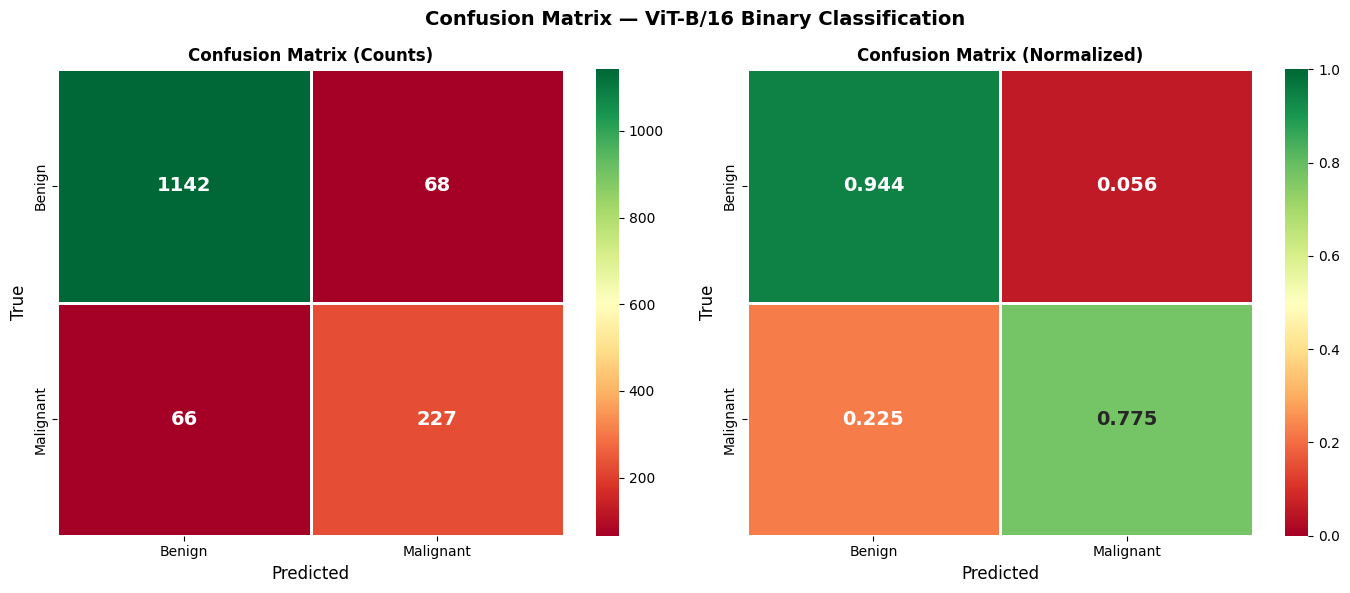


────────────────────────────────────────
  True Negatives  (TN): 1142  ← Benign  → Benign  ✅
  False Positives (FP):   68  ← Benign  → Malignant
  False Negatives (FN):   66  ← Malignant → Benign ⚠️
  True Positives  (TP):  227  ← Malignant → Malignant ✅
────────────────────────────────────────
  FN=66 means 66 cancer cases MISSED
  FP=68 means 68 unnecessary referrals
✅ Confusion matrix saved!


In [23]:
#@title CELL 11 — Confusion Matrix
cm_mat = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm_mat.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(cm_mat, annot=True, fmt='d',
            cmap='RdYlGn',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'],
            ax=axes[0], linewidths=1,
            annot_kws={'size':14, 'weight':'bold'})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)',
                  fontsize=12, fontweight='bold')

# Normalized
cm_norm = cm_mat.astype(float) / \
          cm_mat.sum(axis=1)[:,np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f',
            cmap='RdYlGn',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'],
            ax=axes[1], linewidths=1, vmin=0, vmax=1,
            annot_kws={'size':14, 'weight':'bold'})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix — ViT-B/16 Binary Classification',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE}/assets/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'─'*40}")
print(f"  True Negatives  (TN): {tn:4d}  ← Benign  → Benign  ✅")
print(f"  False Positives (FP): {fp:4d}  ← Benign  → Malignant")
print(f"  False Negatives (FN): {fn:4d}  ← Malignant → Benign ⚠️")
print(f"  True Positives  (TP): {tp:4d}  ← Malignant → Malignant ✅")
print(f"{'─'*40}")
print(f"  FN={fn} means {fn} cancer cases MISSED")
print(f"  FP={fp} means {fp} unnecessary referrals")
print("✅ Confusion matrix saved!")

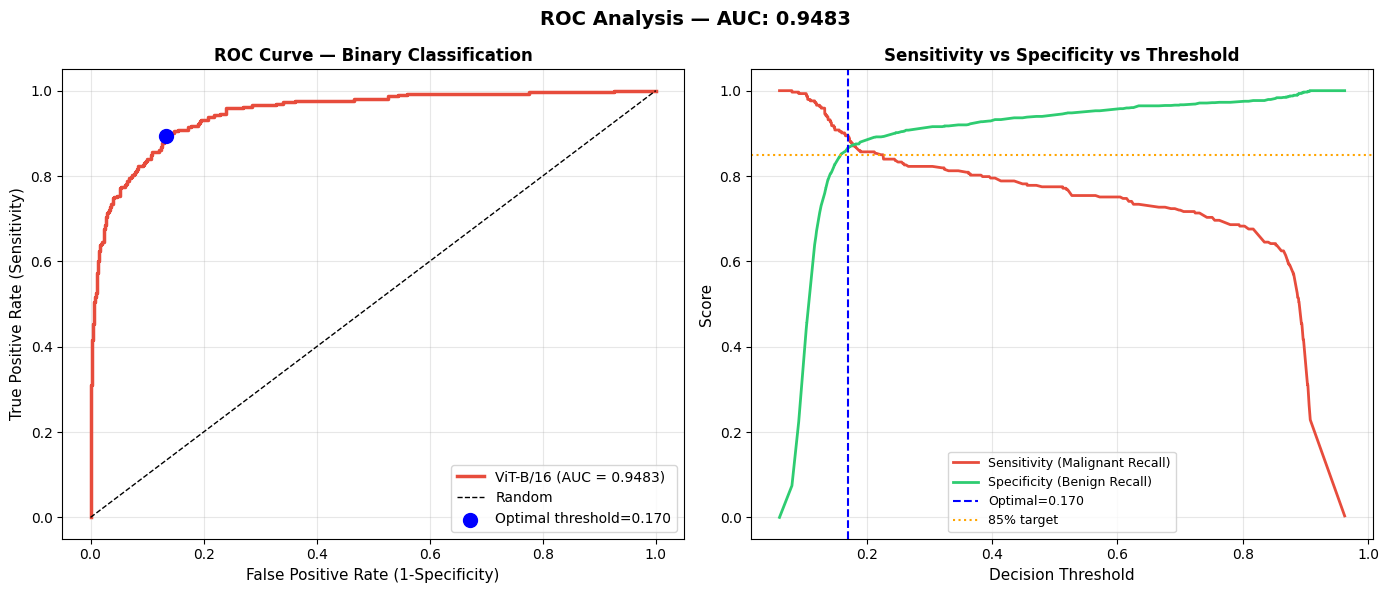

✅ ROC curve saved!
   AUC-ROC          : 0.9483
   Optimal threshold: 0.1699
   At this threshold:
     Sensitivity : 89.42%
     Specificity : 86.69%


In [25]:
#@title CELL 12 — ROC Curve (Binary)
fpr, tpr, thresholds = roc_curve(all_labels, mal_probs)
roc_auc_val          = auc(fpr, tpr)

# Find optimal threshold (max sensitivity + specificity)
optimal_idx = np.argmax(tpr - fpr)
optimal_thr = thresholds[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2.5,
             label=f'ViT-B/16 (AUC = {roc_auc_val:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1, label='Random')
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx],
                color='blue', s=100, zorder=5,
                label=f'Optimal threshold={optimal_thr:.3f}')
axes[0].set_xlabel('False Positive Rate (1-Specificity)',
                   fontsize=11)
axes[0].set_ylabel('True Positive Rate (Sensitivity)',
                   fontsize=11)
axes[0].set_title('ROC Curve — Binary Classification',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Sensitivity vs Specificity vs Threshold
axes[1].plot(thresholds, tpr, color='#e74c3c', lw=2,
             label='Sensitivity (Malignant Recall)')
axes[1].plot(thresholds, 1-fpr, color='#2ecc71', lw=2,
             label='Specificity (Benign Recall)')
axes[1].axvline(x=optimal_thr, color='blue',
                linestyle='--', lw=1.5,
                label=f'Optimal={optimal_thr:.3f}')
axes[1].axhline(y=0.85, color='orange',
                linestyle=':', lw=1.5,
                label='85% target')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Sensitivity vs Specificity vs Threshold',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f'ROC Analysis — AUC: {roc_auc_val:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE}/assets/roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ ROC curve saved!")
print(f"   AUC-ROC          : {roc_auc_val:.4f}")
print(f"   Optimal threshold: {optimal_thr:.4f}")
print(f"   At this threshold:")
print(f"     Sensitivity : {tpr[optimal_idx]*100:.2f}%")
print(f"     Specificity : {(1-fpr[optimal_idx])*100:.2f}%")

✅ Captured: 12 attention tensors
   Model confidence: 92.2% Malignant


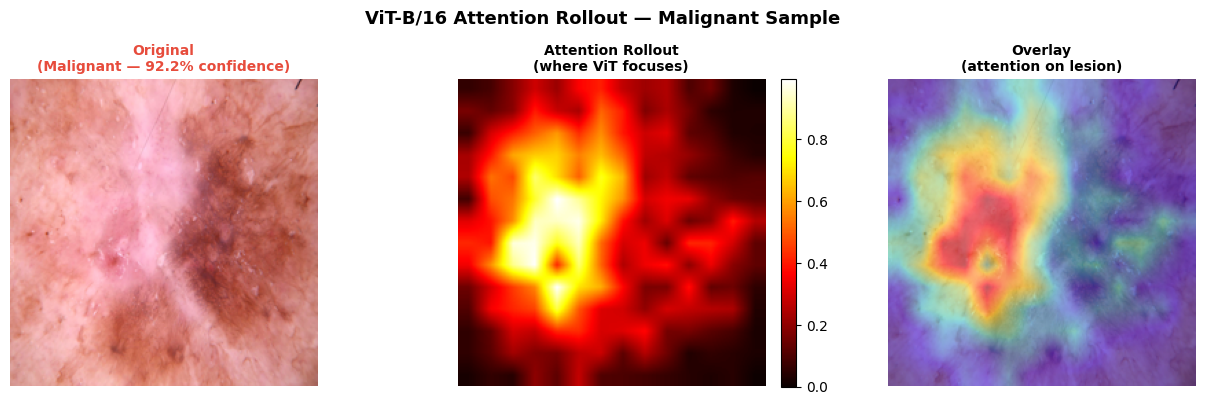

✅ Attention map saved!


In [27]:
#@title CELL 13 — Attention Rollout
attentions = []
hooks      = []

for block in model.blocks:
    hooks.append(block.attn.register_forward_hook(
        lambda m,i,o: attentions.append(
            torch.softmax(
                (i[0] @ i[0].transpose(-2,-1)) /
                (i[0].shape[-1]**0.5), dim=-1
            ).detach().cpu()
        )
    ))

# Pick a malignant sample
mal_row    = test_df[test_df['label']==1].iloc[0]
img_pil    = Image.open(mal_row['path']).convert('RGB')
img_tensor = base_transforms(img_pil)

model.eval()
with torch.no_grad():
    out = model(img_tensor.unsqueeze(0).to(device))
    prob_mal = torch.softmax(out, dim=1)[0,1].item()

for h in hooks:
    h.remove()

print(f"✅ Captured: {len(attentions)} attention tensors")
print(f"   Model confidence: {prob_mal*100:.1f}% Malignant")

def rollout(attentions):
    result = torch.eye(attentions[0].shape[-1])
    for attn in attentions:
        a      = attn.squeeze(0)
        a      = a + torch.eye(a.shape[-1])
        a      = a / a.sum(dim=-1, keepdim=True)
        result = torch.mm(a, result)
    mask = result[0,1:].reshape(14,14).numpy()
    mask = (mask-mask.min())/(mask.max()-mask.min()+1e-8)
    return mask

mask         = rollout(attentions)
mask_resized = cv2.resize(mask,(224,224))
img_np       = np.array(img_pil.resize((224,224)))
heatmap      = (cm.jet(mask_resized)[:,:,:3]*255
                ).astype(np.uint8)
overlay      = (0.55*img_np+0.45*heatmap).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(13,4))
axes[0].imshow(img_np)
axes[0].set_title(f'Original\n(Malignant — {prob_mal*100:.1f}% confidence)',
                  fontsize=10, color='#e74c3c', fontweight='bold')
axes[0].axis('off')

im = axes[1].imshow(mask_resized, cmap='hot')
axes[1].set_title('Attention Rollout\n(where ViT focuses)',
                  fontsize=10, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(overlay)
axes[2].set_title('Overlay\n(attention on lesion)',
                  fontsize=10, fontweight='bold')
axes[2].axis('off')

plt.suptitle('ViT-B/16 Attention Rollout — Malignant Sample',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE}/assets/attention_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Attention map saved!")

In [28]:
#@title CELL 14 — Gradio Demo App
import gradio as gr

model.eval()

def predict(image):
    img       = Image.fromarray(image).convert('RGB')
    probs_all = np.zeros(NUM_CLASSES)

    for t in tta_transforms:
        tensor = t(img).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(tensor)
        probs_all += torch.softmax(out,dim=1
                                   ).cpu().numpy()[0]
    probs_all /= len(tta_transforms)

    mal_prob = probs_all[1]
    ben_prob = probs_all[0]

    if mal_prob >= 0.5:
        verdict = "🔴 MALIGNANT"
        advice  = "High risk detected. Please consult a dermatologist immediately."
        color   = "red"
    else:
        verdict = "🟢 BENIGN"
        advice  = "Low risk detected. Continue monitoring regularly."
        color   = "green"

    return (
        {"Benign": float(ben_prob),
         "Malignant": float(mal_prob)},
        f"**{verdict}** ({mal_prob*100:.1f}% malignant probability)\n\n"
        f"{advice}"
    )

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(label="Upload Dermoscopy Image"),
    outputs=[
        gr.Label(num_top_classes=2,
                 label="Class Probabilities"),
        gr.Markdown(label="Clinical Risk Assessment")
    ],
    title="🔬 Skin Lesion Malignancy Detector — ViT-B/16",
    description=(
        "Upload a dermoscopy image to detect malignancy risk. "
        "Model uses Vision Transformer with Test Time Augmentation. "
        "⚠️ For research purposes only — not a clinical tool."
    )
)
demo.launch(share=True)
print("✅ Gradio app launched!")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://693b72701e069f384a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Gradio app launched!
